In [21]:
from google.colab import drive
import os
import numpy as np
import cv2
import random
import plotly.graph_objects as go
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
project_path = '/content/drive/MyDrive/CV-AR-Viewer'
os.makedirs(os.path.join(project_path, 'input_images'), exist_ok=True)
os.makedirs(os.path.join(project_path, 'colmap_output'), exist_ok=True)
os.makedirs(os.path.join(project_path, 'models'), exist_ok=True)

In [4]:
video_path = '/content/drive/MyDrive/CV-AR-Viewer/video_raw/raw-tabletop-video.mp4'
output_dir = '/content/drive/MyDrive/CV-AR-Viewer/input_images'
frame_skip = 10

def extract_frames(video_file, out_folder, skip):
    cap = cv2.VideoCapture(video_file)

    if not cap.isOpened():
        print("Error: Could not open video.")
        return

    frame_count = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % skip == 0:
            frame_name = os.path.join(out_folder, f"frame_{saved_count:04d}.jpg")
            cv2.imwrite(frame_name, frame)
            saved_count += 1

        frame_count += 1

    cap.release()
    print(f"Extraction complete! Saved {saved_count} frames to {out_folder}")

# extract_frames(video_path, output_dir, frame_skip)

Extraction complete! Saved 68 frames to /content/drive/MyDrive/CV-AR-Viewer/input_images


In [5]:
def load_points3D(filepath):
    points = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue

            parts = line.split()
            if len(parts) >= 4:
                # Extract X, Y, Z coordinates
                x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                points.append([x, y, z])

    return np.array(points)

points3d_path = os.path.join(project_path, 'colmap_output', 'points3D.txt')

scene_points = load_points3D(points3d_path)
print(f"Loaded {len(scene_points)} 3D points.")

Loaded 23623 3D points.


In [6]:
def load_points3D(filepath):
    """Reads points3D.txt and extracts X, Y, Z coordinates."""
    points = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            parts = line.split()
            if len(parts) >= 4:
                x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                points.append([x, y, z])
    return np.array(points)

In [7]:
def fit_plane(p1, p2, p3):
    """Calculates the plane equation Ax + By + Cz + D = 0 given 3 points."""
    v1 = p2 - p1
    v2 = p3 - p1

    # Cross product gives the normal vector to the plane
    normal = np.cross(v1, v2)
    norm_length = np.linalg.norm(normal)

    # Check if points are collinear
    if norm_length < 1e-6:
        return None

    normal = normal / norm_length
    A, B, C = normal
    D = -np.dot(normal, p1)

    return A, B, C, D

In [8]:
def run_ransac(points, iterations=2000, distance_threshold=0.05):
    """Finds the largest coplanar set of points."""
    best_plane = None
    best_inliers = []
    num_points = len(points)

    for _ in range(iterations):
        # 1. Randomly sample 3 points
        idx = random.sample(range(num_points), 3)
        p1, p2, p3 = points[idx[0]], points[idx[1]], points[idx[2]]

        # 2. Fit the plane
        plane = fit_plane(p1, p2, p3)
        if plane is None:
            continue
        A, B, C, D = plane

        # 3. Calculate distance from all points to this plane
        # Since the normal vector [A, B, C] is normalized, the denominator is 1.
        distances = np.abs(np.dot(points, [A, B, C]) + D)

        # 4. Find inliers
        inlier_indices = np.where(distances < distance_threshold)[0]

        # 5. Update the best plane if this one has more inliers
        if len(inlier_indices) > len(best_inliers):
            best_inliers = inlier_indices
            best_plane = plane

    return best_plane, best_inliers


In [9]:
# --- Execution --- #
points3d_path = os.path.join(project_path, 'colmap_output', 'points3D.txt')
scene_points = load_points3D(points3d_path)
print(f"Loaded {len(scene_points)} points.")

dominant_plane, inlier_indices = run_ransac(scene_points)
print(f"Found dominant plane with {len(inlier_indices)} inliers out of {len(scene_points)} points.")

Loaded 23623 points.
Found dominant plane with 17393 inliers out of 23623 points.


In [11]:
inlier_points = scene_points[inlier_indices]
outlier_mask = np.ones(len(scene_points), dtype=bool)
outlier_mask[inlier_indices] = False
outlier_points = scene_points[outlier_mask]

fig = go.Figure()
fig.add_trace(go.Scatter3d(x=outlier_points[:,0], y=outlier_points[:,1], z=outlier_points[:,2],
                           mode='markers', marker=dict(size=1, color='gray'), name='Outliers'))
fig.add_trace(go.Scatter3d(x=inlier_points[:,0], y=inlier_points[:,1], z=inlier_points[:,2],
                           mode='markers', marker=dict(size=2, color='red'), name='Inliers (Plane)'))

fig.update_layout(title='3D Point Cloud - Red points represent the dominant plane',
                  scene=dict(aspectmode='data'), margin=dict(l=0, r=0, b=0, t=0))
fig.show()

In [12]:
origin = np.mean(inlier_points, axis=0)

A, B, C, D = dominant_plane
z_axis = np.array([A, B, C])

if np.dot(z_axis, origin) > 0:
    z_axis = -z_axis

temp_vec = np.array([1, 0, 0]) if np.abs(z_axis[0]) < 0.9 else np.array([0, 1, 0])
x_axis = np.cross(temp_vec, z_axis)
x_axis /= np.linalg.norm(x_axis)

y_axis = np.cross(z_axis, x_axis)

R_local_to_scene = np.column_stack((x_axis, y_axis, z_axis))
T_local_to_scene = origin

print("Rotation Matrix (Local to Scene):\n", R_local_to_scene)
print("Translation Vector (Local to Scene):\n", T_local_to_scene)

Rotation Matrix (Local to Scene):
 [[ 0.          0.99620085  0.08708534]
 [ 0.5364214   0.0734957  -0.840744  ]
 [-0.84395029  0.04671444 -0.53438345]]
Translation Vector (Local to Scene):
 [-0.08834453  3.92709112  1.60326111]


In [36]:
def load_icosahedron(filepath):
    """Parses vertices and faces, handling potential line breaks in the text file."""
    with open(filepath, 'r') as f:
        content = f.read().replace('\n', ' ').split()

    vertices = []
    faces = []

    i = 0
    while i < len(content):
        if content[i] == 'v':
            vertices.append([float(content[i+1]), float(content[i+2]), float(content[i+3])])
            i += 4
        elif content[i] == 'f':
            faces.append([int(content[i+1])-1, int(content[i+2])-1, int(content[i+3])-1])
            i += 4
        else:
            i += 1

    return np.array(vertices), np.array(faces)

icosahedron_path = os.path.join(project_path, 'models', 'icosahedron.txt')
vertices_local, faces = load_icosahedron(icosahedron_path)

bottom_vertices = vertices_local[np.abs(vertices_local[:, 2]) < 1e-5]
bottom_centroid = np.mean(bottom_vertices, axis=0)

vertices_centered = vertices_local - bottom_centroid

scale_factor = 0.3
vertices_scaled = vertices_centered * scale_factor

table_height_offset = 1.5
vertices_scaled[:, 2] += table_height_offset

R_local_to_scene = np.array([
    [ 0.0,         0.99620085,  0.08708534],
    [ 0.5364214,   0.0734957,  -0.840744  ],
    [-0.84395029,  0.04671444, -0.53438345]
])
T_local_to_scene = np.array([-0.08834453,  3.92709112,  1.60326111])

vertices_scene = (R_local_to_scene @ vertices_scaled.T).T + T_local_to_scene

fig = go.Figure()
fig.add_trace(go.Scatter3d(x=outlier_points[:,0], y=outlier_points[:,1], z=outlier_points[:,2],
                           mode='markers', marker=dict(size=1, color='gray'), name='Outliers'))
fig.add_trace(go.Scatter3d(x=inlier_points[:,0], y=inlier_points[:,1], z=inlier_points[:,2],
                           mode='markers', marker=dict(size=2, color='red'), name='Inliers (Plane)'))

fig.add_trace(go.Mesh3d(
    x=vertices_scene[:, 0],
    y=vertices_scene[:, 1],
    z=vertices_scene[:, 2],
    i=faces[:, 0],
    j=faces[:, 1],
    k=faces[:, 2],
    color='cyan',
    opacity=0.80,
    name='Virtual Icosahedron'
))

fig.update_layout(title='3D Scene with Virtual Icosahedron Overlay',
                  scene=dict(aspectmode='data'), margin=dict(l=0, r=0, b=0, t=0))
fig.show()

In [37]:
def read_cameras_text(path):
    """Parses cameras.txt to get internal parameters[cite: 97, 98]."""
    cameras = {}
    with open(path, "r") as fid:
        for line in fid:
            if line.startswith("#"):
                continue
            elems = line.split()
            camera_id = int(elems[0])
            model = elems[1]
            width = int(elems[2])
            height = int(elems[3])
            params = np.array(tuple(map(float, elems[4:])))
            cameras[camera_id] = {'model': model, 'width': width, 'height': height, 'params': params}
    return cameras


In [38]:
def read_images_text(path):
    """Parses images.txt to get external parameters (camera poses)[cite: 99, 100]."""
    images = {}
    with open(path, "r") as fid:
        while True:
            line = fid.readline()
            if not line:
                break
            line = line.strip()
            if len(line) > 0 and line.startswith("#"):
                continue

            elems = line.split()
            image_id = int(elems[0])

            qvec = np.array(tuple(map(float, elems[1:5])))
            tvec = np.array(tuple(map(float, elems[5:8])))
            camera_id = int(elems[8])
            image_name = elems[9]

            fid.readline()

            scipy_quat = [qvec[1], qvec[2], qvec[3], qvec[0]]
            R_matrix = Rotation.from_quat(scipy_quat).as_matrix()

            images[image_id] = {
                'qvec': qvec,
                'tvec': tvec,
                'R': R_matrix,
                'camera_id': camera_id,
                'name': image_name
            }
    return images


In [39]:
cameras_path = os.path.join(project_path, 'colmap_output', 'cameras.txt')
images_path = os.path.join(project_path, 'colmap_output', 'images.txt')

cameras = read_cameras_text(cameras_path)
images = read_images_text(images_path)

print(f"Loaded {len(cameras)} camera models.")
print(f"Loaded {len(images)} image poses.")

cam_id = list(cameras.keys())[0]
print(f"\nCamera {cam_id} ({cameras[cam_id]['model']}) parameters: {cameras[cam_id]['params']}")

Loaded 1 camera models.
Loaded 68 image poses.

Camera 1 (SIMPLE_RADIAL) parameters: [6.83694635e+02 3.60000000e+02 6.40000000e+02 5.02474203e-03]


In [40]:
def project_points_pinhole(points3D, R, tvec, f, cx, cy):
    """Custom 3D to 2D projection ignoring radial distortion."""
    points_cam = (R @ points3D.T).T + tvec

    Z = points_cam[:, 2]

    x_norm = points_cam[:, 0] / Z
    y_norm = points_cam[:, 1] / Z

    u = f * x_norm + cx
    v = f * y_norm + cy

    return np.column_stack((u, v)), Z

def render_ar_frame(image_path, vertices_scene, faces, R, tvec, f, cx, cy):
    img = cv2.imread(image_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    pts_2d, depths = project_points_pinhole(vertices_scene, R, tvec, f, cx, cy)

    face_depths = []
    valid_faces = []

    for face in faces:
        z1, z2, z3 = depths[face[0]], depths[face[1]], depths[face[2]]

        if z1 > 0 and z2 > 0 and z3 > 0:
            min_z = min(z1, z2, z3)
            face_depths.append(min_z)
            valid_faces.append(face)

    sort_idx = np.argsort(face_depths)[::-1]

    overlay = img.copy()

    for idx in sort_idx:
        face = valid_faces[idx]
        pt1, pt2, pt3 = pts_2d[face[0]], pts_2d[face[1]], pts_2d[face[2]]

        poly_pts = np.array([pt1, pt2, pt3], np.int32).reshape((-1, 1, 2))

        cv2.fillPoly(overlay, [poly_pts], color=(0, 255, 255))
        cv2.polylines(overlay, [poly_pts], isClosed=True, color=(0, 200, 200), thickness=2)

    return overlay



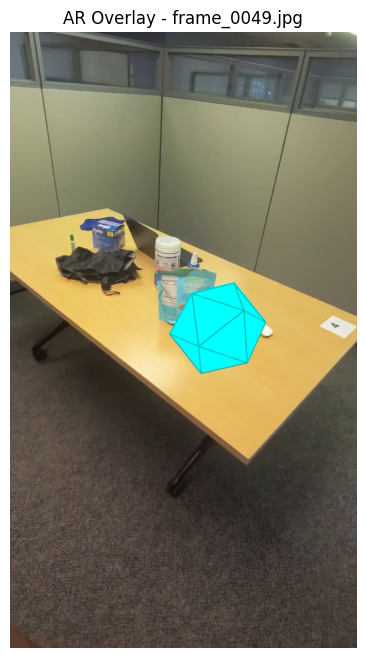

In [41]:
# --- Test Rendering on the First Image --- #
cam_params = cameras[1]['params']
f, cx, cy = cam_params[0], cam_params[1], cam_params[2]

first_image_id = list(images.keys())[0]
img_data = images[first_image_id]
image_filename = img_data['name']
R_cam = img_data['R']
tvec_cam = img_data['tvec']

img_path = os.path.join(project_path, 'input_images', image_filename)

result_img = render_ar_frame(img_path, vertices_scene, faces, R_cam, tvec_cam, f, cx, cy)

plt.figure(figsize=(10, 8))
plt.imshow(result_img)
plt.axis('off')
plt.title(f"AR Overlay - {image_filename}")
plt.show()

In [43]:
os.makedirs(os.path.join(project_path, 'video_out'), exist_ok=True)
video_out_path = os.path.join(project_path, 'video_out', 'icosahedron_ar_video.mp4')

ordered_images = sorted(images.values(), key=lambda x: x['name'])

fps = 3
frame_width = cameras[1]['width']
frame_height = cameras[1]['height']
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(video_out_path, fourcc, fps, (frame_width, frame_height))

print("Rendering AR frames...")

for img_data in ordered_images:
    img_name = img_data['name']
    img_path = os.path.join(project_path, 'input_images', img_name)

    R_cam = img_data['R']
    tvec_cam = img_data['tvec']

    rgb_frame = render_ar_frame(img_path, vertices_scene, faces, R_cam, tvec_cam, f, cx, cy)

    if rgb_frame is not None:
        bgr_frame = cv2.cvtColor(rgb_frame, cv2.COLOR_RGB2BGR)
        out.write(bgr_frame)

out.release()
print(f"Success! AR Video saved to {video_out_path}")

Rendering AR frames...
Success! AR Video saved to /content/drive/MyDrive/CV-AR-Viewer/video_out/icosahedron_ar_video.mp4
